## Article Coverage Across Time

This notebook examines the article timeseries stored in the `articles` database table and investigates how the dataset is distributed over time.

The objective is to understand where the collection is strongest by looking at:

- **Years** with the broadest and sparsest coverage
- **Months** where article volume is most concentrated
- **Days** that show unusual spikes or gaps in activity

Together, these views reveal which periods are most thoroughly represented in the dataset and where coverage may be uneven or incomplete.

In [118]:
import os
from dotenv import load_dotenv
load_dotenv()

from sqlalchemy import create_engine, text

import pandas as pd


database_url = os.environ.get("DATABASE_URL")
database_engine = create_engine(url=database_url) # type: ignore

connection = database_engine.connect()

In [119]:
query = """
SELECT 
    a.published_at::date AS published_date,
    count(a.published_at) AS article_count
FROM
    articles AS a
GROUP BY 1
ORDER BY 1
;"""
df = pd.read_sql(query, con=database_engine, parse_dates=True) # type: ignore


In [70]:
import dayplot
import numpy as np
from datetime import date
import matplotlib.pyplot as plt

### Article Counts Overtime
A quick plot showing the number of articles per day over time.

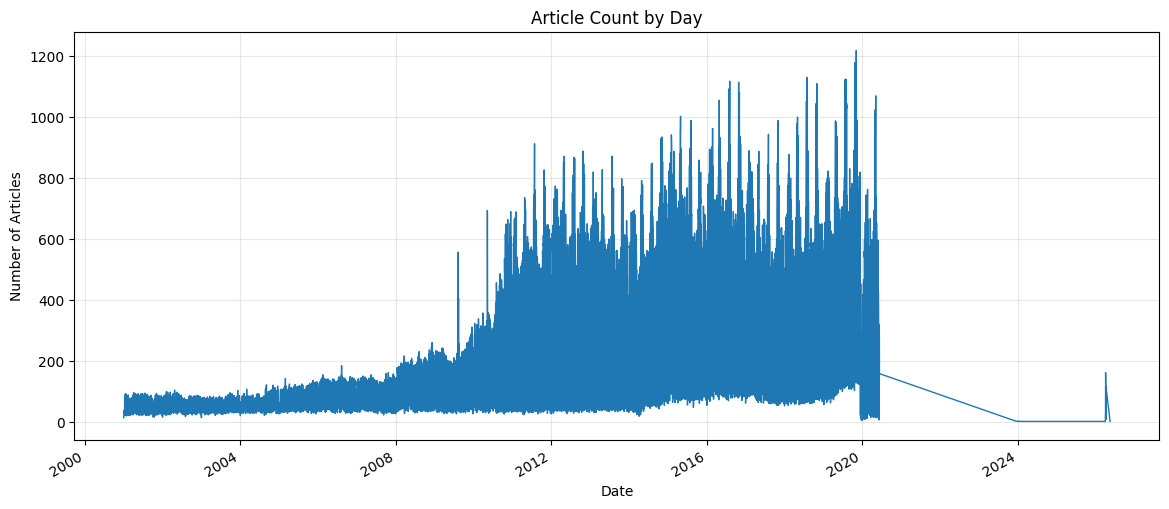

In [105]:
daily_counts = df[df["published_date"].dt.year > 2000].sort_values("published_date")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily_counts["published_date"], daily_counts["article_count"], linewidth=1)
ax.set_title("Article Count by Day")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Articles")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.show()

### Calendar Plot

This calendar plot shows the distribution of article counts across each day of the year, making it easy to compare coverage patterns between years. Dense clusters indicate periods of higher news activity, while sparse or empty stretches highlight gaps in the dataset.

Its significance is that it reveals seasonality, collection bias, and incomplete coverage at a glance. This helps identify which time periods are well represented and which may need additional data sources or cleanup.

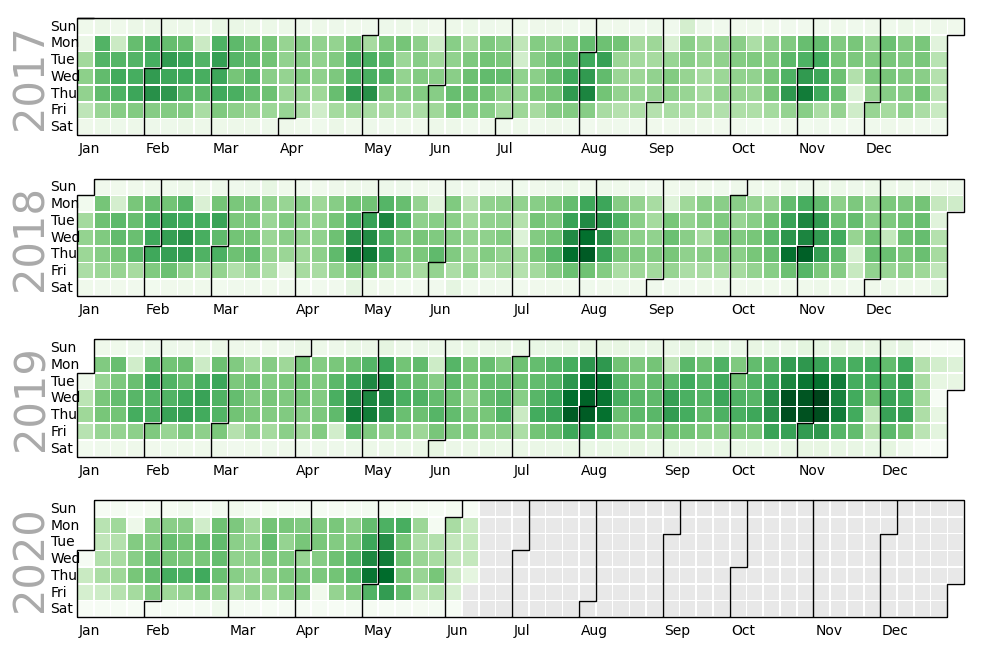

In [179]:
years = np.arange(2017,2021)

fig, ax = plt.subplots(nrows=len(years), figsize=(12, 2*len(years)))

for axes, year in zip(ax, years):
    # axes.set_visible(False)
    g = dayplot.calendar(
        dates=df["published_date"].to_list(),
        values=df["article_count"].to_list(),
        start_date=date.fromisoformat(f"{year}-01-01"),
        end_date=date.fromisoformat(f"{year}-12-31"),
        month_grid=True,
        ax=axes
)
    text_args = dict(x=-4, y=3.5, size=30, rotation=90, color="#aaa", va="center")
    axes.text(s=str(year), **text_args)